In [1]:
from icecube import dataio, LeptonInjector, simclasses

path = "/home/kbas/scratch/String340MC_pone_offline_version3/Muon_PMT_Response/muon_cls_000.i3.gz"

i3_file = dataio.I3File(path, "r")

selected_frame = None

while i3_file.more():
    frame = i3_file.pop_frame()

    if "EventProperties" not in frame:
        continue

    energy = float(frame["EventProperties"].totalEnergy)
    if not (1e4 <= energy <= 1e5):
        continue

    if "triggered_340_string" not in frame:
        continue

    triggered = float(frame["triggered_340_string"].value)
    if triggered != 1:
        continue

    if "Accepted_PulseMap_340String" not in frame or "MMCTrackList" not in frame:
        continue

    selected_frame = frame
    print(frame["triggered_340_string"])
    print(frame["Accepted_PulseMap_340String"])
    print(frame["MMCTrackList"])
    break

i3_file.close()


I3Double(1)
[OMKey(94,18,8) => [[ I3MCPE::
  Time :19473.4
  NPE  :1
  I3ParticleID(3019218780441209185, 5261) ]],
OMKey(112,18,10) => [[ I3MCPE::
  Time :19181.4
  NPE  :1
  I3ParticleID(3019218780441209185, 5255) ]],
OMKey(112,18,15) => [[ I3MCPE::
  Time :19183.2
  NPE  :1
  I3ParticleID(3019218780441209185, 5253) ]],
OMKey(112,19,14) => [[ I3MCPE::
  Time :19159.7
  NPE  :1
  I3ParticleID(3019218780441209185, 5253) ]],
OMKey(112,19,15) => [[ I3MCPE::
  Time :19159.7
  NPE  :1
  I3ParticleID(3019218780441209185, 5253) ]],
OMKey(113,18,9) => [[ I3MCPE::
  Time :19357.8
  NPE  :1
  I3ParticleID(3019218780441209185, 5259) ]],
OMKey(113,18,12) => [[ I3MCPE::
  Time :19346.2
  NPE  :1
  I3ParticleID(3019218780441209185, 5257) ]],
OMKey(113,18,13) => [[ I3MCPE::
  Time :19348.5
  NPE  :1
  I3ParticleID(3019218780441209185, 5257) ]
 [ I3MCPE::
  Time :19362.5
  NPE  :1
  I3ParticleID(3019218780441209185, 5259) ]],
OMKey(113,18,14) => [[ I3MCPE::
  Time :19353.4
  NPE  :1
  I3ParticleID(301

/tmp/ipykernel_4159679/443851936.py:164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


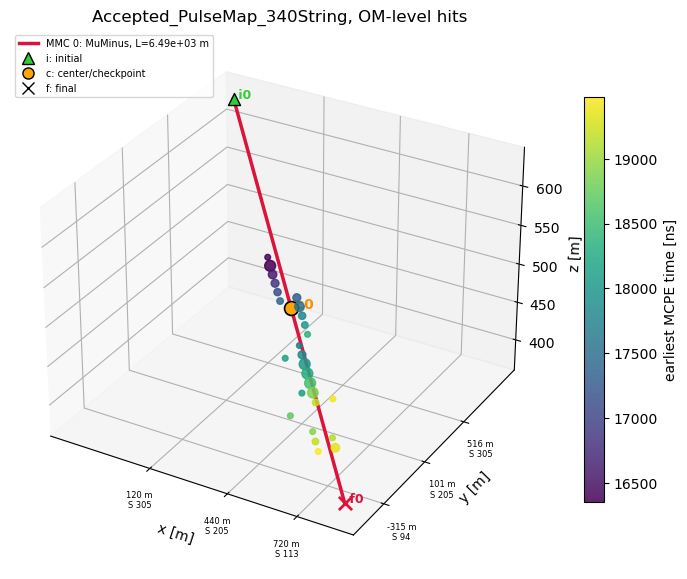

In [2]:
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

GCD_PATH = "/project/6008051/pone_simulation/GCD_Library/PONE_800mGrid.i3.gz"


def read_geometry_frame(gcd_path):
    gcd_file = dataio.I3File(gcd_path, "r")
    while gcd_file.more():
        frame = gcd_file.pop_frame()
        if frame.Stop == frame.Geometry:
            gcd_file.close()
            return frame
    gcd_file.close()
    raise RuntimeError(f"No Geometry frame found in {gcd_path}")


def pe_charge(pe):
    if hasattr(pe, "npe"):
        return float(pe.npe)
    if hasattr(pe, "NPE"):
        return float(pe.NPE)
    return 1.0


def pe_time(pe):
    if hasattr(pe, "time"):
        return float(pe.time)
    return float(pe.Time)


if selected_frame is None:
    raise RuntimeError("No selected frame. Run the frame-selection cell first.")

geometry = read_geometry_frame(GCD_PATH)["I3Geometry"].omgeo
pulse_map = selected_frame["Accepted_PulseMap_340String"]

om_hits = defaultdict(lambda: {"x": [], "y": [], "z": [], "charge": 0.0, "time": None, "pmts": set()})

for omkey, pulses in pulse_map.items():
    if omkey not in geometry:
        continue

    pos = geometry[omkey].position
    om_id = (int(omkey.string), int(omkey.om))
    pmt = int(omkey.pmt) if hasattr(omkey, "pmt") else int(omkey.pmt_id)

    om_hits[om_id]["x"].append(float(pos.x))
    om_hits[om_id]["y"].append(float(pos.y))
    om_hits[om_id]["z"].append(float(pos.z))
    om_hits[om_id]["pmts"].add(pmt)

    for pe in pulses:
        q = pe_charge(pe)
        t = pe_time(pe)
        om_hits[om_id]["charge"] += q
        if om_hits[om_id]["time"] is None or t < om_hits[om_id]["time"]:
            om_hits[om_id]["time"] = t

xs, ys, zs, charges, times, labels = [], [], [], [], [], []
for (string, om), hit in sorted(om_hits.items()):
    if hit["charge"] <= 0 or hit["time"] is None:
        continue

    xs.append(sum(hit["x"]) / len(hit["x"]))
    ys.append(sum(hit["y"]) / len(hit["y"]))
    zs.append(sum(hit["z"]) / len(hit["z"]))
    charges.append(hit["charge"])
    times.append(hit["time"])
    labels.append(f"{string},{om} ({len(hit['pmts'])} PMTs)")

sizes = [12 + 5 * min(q, 10) for q in charges]


TRACK_COLORS = ["crimson", "royalblue", "darkorange", "purple", "seagreen", "black"]


def mmc_track_segments(frame):
    segments = []
    for i, track in enumerate(frame["MMCTrackList"]):
        try:
            start = (float(track.xi), float(track.yi), float(track.zi))
            center = (float(track.xc), float(track.yc), float(track.zc))
            stop = (float(track.xf), float(track.yf), float(track.zf))
        except AttributeError:
            continue

        particle = getattr(track, "particle", None)
        particle_type = str(getattr(particle, "type", f"track_{i}"))
        length = float(getattr(particle, "length", 0.0)) if particle is not None else 0.0
        color = TRACK_COLORS[i % len(TRACK_COLORS)]
        segments.append({
            "index": i,
            "start": start,
            "center": center,
            "stop": stop,
            "color": color,
            "label": f"MMC {i}: {particle_type}, L={length:.3g} m",
        })
    return segments

mmc_segments = mmc_track_segments(selected_frame)

def axis_ticks_with_string_ids(values, labels, max_ticks=3):
    value_to_strings = {}
    for value, label in zip(values, labels):
        key = round(value, 1)
        string = label.split(",")[0]
        value_to_strings.setdefault(key, set()).add(string)
    ticks = sorted(value_to_strings)
    if len(ticks) > max_ticks:
        idxs = [round(i * (len(ticks) - 1) / (max_ticks - 1)) for i in range(max_ticks)]
        ticks = [ticks[i] for i in idxs]
    tick_labels = [
        f"{tick:.0f} m\nS {','.join(sorted(value_to_strings[tick], key=int))}"
        for tick in ticks
    ]
    return ticks, tick_labels

x_ticks, x_tick_labels = axis_ticks_with_string_ids(xs, labels, max_ticks=3)
y_ticks, y_tick_labels = axis_ticks_with_string_ids(ys, labels, max_ticks=3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(xs, ys, zs, c=times, s=sizes, cmap="viridis", alpha=0.85)

for seg in mmc_segments:
    idx = seg["index"]
    color = seg["color"]
    x0, y0, z0 = seg["start"]
    xc, yc, zc = seg["center"]
    x1, y1, z1 = seg["stop"]
    ax.plot([x0, x1], [y0, y1], [z0, z1], color=color, linewidth=2.5, label=seg["label"])
    ax.scatter([x0], [y0], [z0], marker="^", s=75, color="limegreen", edgecolor="black", linewidth=1.0, depthshade=False)
    ax.scatter([xc], [yc], [zc], marker="o", s=100, color="orange", edgecolor="black", linewidth=1.2, depthshade=False)
    ax.scatter([x1], [y1], [z1], marker="x", s=90, color=color, linewidth=2.0, depthshade=False)
    ax.text(x0, y0, z0, f" i{idx}", color="limegreen", fontsize=9, fontweight="bold")
    ax.text(xc, yc, zc, f" c{idx}", color="darkorange", fontsize=10, fontweight="bold")
    ax.text(x1, y1, z1, f" f{idx}", color=color, fontsize=9, fontweight="bold")

if mmc_segments:
    legend_handles = [
        Line2D([0], [0], color=seg["color"], lw=2.5, label=seg["label"])
        for seg in mmc_segments
    ]
    legend_handles += [
        Line2D([0], [0], marker="^", color="none", markerfacecolor="limegreen", markeredgecolor="black", markersize=8, label="i: initial"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="orange", markeredgecolor="black", markersize=8, label="c: center/checkpoint"),
        Line2D([0], [0], marker="x", color="black", markersize=8, linestyle="None", label="f: final"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=7)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels, fontsize=6)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels, fontsize=6)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("Accepted_PulseMap_340String, OM-level hits")
fig.colorbar(sc, ax=ax, label="earliest MCPE time [ns]", shrink=0.75)
plt.tight_layout()
plt.show()


In [ ]:
# from IPython.display import HTML
# from matplotlib import animation
# from matplotlib.lines import Line2D
# 
# fig = plt.figure(figsize=(8, 7))
# ax = fig.add_subplot(111, projection="3d")
# sc = ax.scatter(xs, ys, zs, c=times, s=sizes, cmap="viridis", alpha=0.85)
# 
# for seg in mmc_segments:
#     idx = seg["index"]
#     color = seg["color"]
#     x0, y0, z0 = seg["start"]
#     xc, yc, zc = seg["center"]
#     x1, y1, z1 = seg["stop"]
#     ax.plot([x0, x1], [y0, y1], [z0, z1], color=color, linewidth=2.5, label=seg["label"])
#     ax.scatter([x0], [y0], [z0], marker="^", s=75, color="limegreen", edgecolor="black", linewidth=1.0, depthshade=False)
#     ax.scatter([xc], [yc], [zc], marker="o", s=100, color="orange", edgecolor="black", linewidth=1.2, depthshade=False)
#     ax.scatter([x1], [y1], [z1], marker="x", s=90, color=color, linewidth=2.0, depthshade=False)
#     ax.text(x0, y0, z0, f" i{idx}", color="limegreen", fontsize=9, fontweight="bold")
#     ax.text(xc, yc, zc, f" c{idx}", color="darkorange", fontsize=10, fontweight="bold")
#     ax.text(x1, y1, z1, f" f{idx}", color=color, fontsize=9, fontweight="bold")
# 
# if mmc_segments:
#     legend_handles = [
#         Line2D([0], [0], color=seg["color"], lw=2.5, label=seg["label"])
#         for seg in mmc_segments
#     ]
#     legend_handles += [
#         Line2D([0], [0], marker="^", color="none", markerfacecolor="limegreen", markeredgecolor="black", markersize=8, label="i: # initial"),
#         Line2D([0], [0], marker="o", color="none", markerfacecolor="orange", markeredgecolor="black", markersize=8, label="c: # center/checkpoint"),
#         Line2D([0], [0], marker="x", color="black", markersize=8, linestyle="None", label="f: final"),
#     ]
#     ax.legend(handles=legend_handles, loc="upper left", fontsize=7)
# 
# ax.set_xticks(x_ticks)
# ax.set_xticklabels(x_tick_labels, fontsize=6)
# ax.set_yticks(y_ticks)
# ax.set_yticklabels(y_tick_labels, fontsize=6)
# 
# z_to_oms = {}
# for z, label in zip(zs, labels):
#     key = round(z, 1)
#     om = label.split(",")[1].split()[0]
#     z_to_oms.setdefault(key, set()).add(om)
# 
# z_ticks = sorted(z_to_oms)
# z_tick_labels = [
#     f"{z:.0f} m\nOM {','.join(sorted(z_to_oms[z], key=int))}"
#     for z in z_ticks
# ]
# ax.set_zticks(z_ticks)
# ax.set_zticklabels(z_tick_labels, fontsize=7)
# 
# ax.set_xlabel("x [m]")
# ax.set_ylabel("y [m]")
# ax.set_zlabel("z [m] / OM id")
# ax.set_title("Accepted_PulseMap_340String, OM-level hits - rotating view")
# fig.colorbar(sc, ax=ax, label="earliest MCPE time [ns]", shrink=0.75)
# 
# ax.view_init(elev=8, azim=-90)
# 
# 
# def update(angle):
#     ax.view_init(elev=8, azim=angle)
#     return (sc,)
# 
# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=range(-90, 270, 3),
#     interval=70,
#     blit=False,
# )
# 
# plt.tight_layout()
# plt.close(fig)
# HTML(ani.to_jshtml())


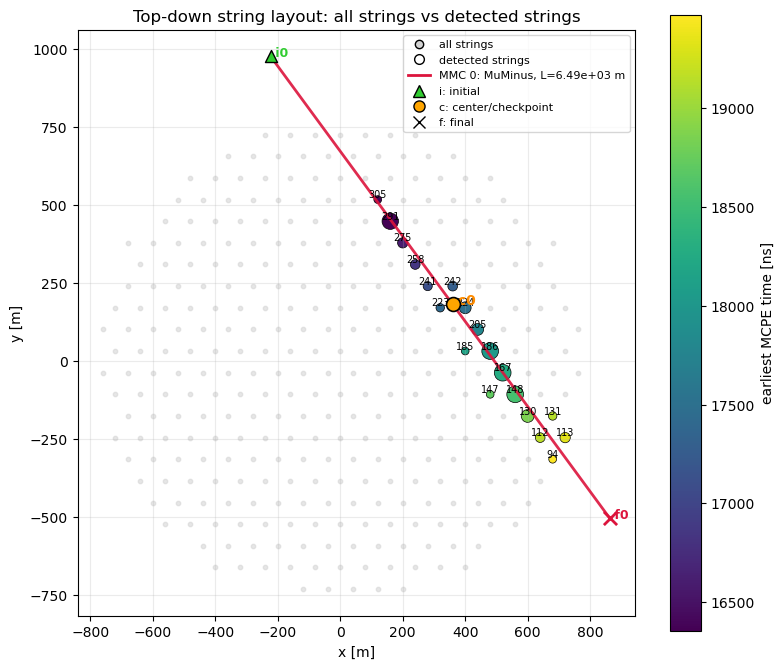

In [4]:
from matplotlib.lines import Line2D
import csv
from pathlib import Path

STRING_COORDS_CSV = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Metadata/GeometryFiles/string_coordinates_340_string_mc.csv"
)

string_coords = {}
with STRING_COORDS_CSV.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        string_coords[int(row["string"])] = (float(row["x"]), float(row["y"]))

detected_strings = sorted({string for (string, om), hit in om_hits.items() if hit["charge"] > 0})
charge_by_string = {string: 0.0 for string in detected_strings}
time_by_string = {string: None for string in detected_strings}

for (string, om), hit in om_hits.items():
    if hit["charge"] <= 0:
        continue
    charge_by_string[string] = charge_by_string.get(string, 0.0) + hit["charge"]
    if time_by_string.get(string) is None or hit["time"] < time_by_string[string]:
        time_by_string[string] = hit["time"]

all_x = [xy[0] for xy in string_coords.values()]
all_y = [xy[1] for xy in string_coords.values()]

detected_in_csv = [string for string in detected_strings if string in string_coords]
det_x = [string_coords[string][0] for string in detected_in_csv]
det_y = [string_coords[string][1] for string in detected_in_csv]
det_t = [time_by_string[string] for string in detected_in_csv]
det_s = [25 + 6 * min(charge_by_string[string], 20) for string in detected_in_csv]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(all_x, all_y, s=10, color="lightgray", alpha=0.55, label="all strings")
sc = ax.scatter(
    det_x,
    det_y,
    s=det_s,
    c=det_t,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5,
    label="detected strings",
)

for string in detected_in_csv:
    x, y = string_coords[string]
    ax.text(x, y, str(string), fontsize=7, ha="center", va="bottom")

ax.set_title("Top-down string layout: all strings vs detected strings")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
for seg in mmc_segments:
    idx = seg["index"]
    color = seg["color"]
    x0, y0, _ = seg["start"]
    xc, yc, _ = seg["center"]
    x1, y1, _ = seg["stop"]
    ax.plot([x0, x1], [y0, y1], color=color, linewidth=2.0, alpha=0.9)
    ax.scatter([x0], [y0], marker="^", s=75, color="limegreen", edgecolor="black", linewidth=1.0, zorder=5)
    ax.scatter([xc], [yc], marker="o", s=100, color="orange", edgecolor="black", linewidth=1.2, zorder=6)
    ax.scatter([x1], [y1], marker="x", s=90, color=color, linewidth=2.0, zorder=5)
    ax.text(x0, y0, f" i{idx}", color="limegreen", fontsize=9, fontweight="bold")
    ax.text(xc, yc, f" c{idx}", color="darkorange", fontsize=10, fontweight="bold")
    ax.text(x1, y1, f" f{idx}", color=color, fontsize=9, fontweight="bold")

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="lightgray", markersize=6, label="all strings"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black", markersize=7, label="detected strings"),
]
legend_handles += [
    Line2D([0], [0], color=seg["color"], lw=2.0, label=seg["label"])
    for seg in mmc_segments
]
legend_handles += [
    Line2D([0], [0], marker="^", color="none", markerfacecolor="limegreen", markeredgecolor="black", markersize=8, label="i: initial"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="orange", markeredgecolor="black", markersize=8, label="c: center/checkpoint"),
    Line2D([0], [0], marker="x", color="black", markersize=8, linestyle="None", label="f: final"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8)
fig.colorbar(sc, ax=ax, label="earliest MCPE time [ns]", shrink=0.8)
plt.tight_layout()
plt.show()


In [5]:
import numpy as np

for idx, track in enumerate(selected_frame["MMCTrackList"]):
    i = np.array([float(track.xi), float(track.yi), float(track.zi)])
    c = np.array([float(track.xc), float(track.yc), float(track.zc)])
    f = np.array([float(track.xf), float(track.yf), float(track.zf)])

    midpoint = 0.5 * (i + f)
    diff = c - midpoint
    dist = np.linalg.norm(diff)

    print(f"Track {idx}")
    print("i       =", i)
    print("c       =", c)
    print("f       =", f)
    print("mid(i,f)=", midpoint)
    print("c - mid =", diff)
    print("|c-mid| =", dist, "m")
    print()

Track 0
i       = [-222.98095311  974.66127196  630.01089835]
c       = [361.34085262 181.31530106 493.28180444]
f       = [ 863.32491751 -504.64847845  377.87229202]
mid(i,f)= [320.1719822  235.00639675 503.94159519]
c - mid = [ 41.16887042 -53.69109569 -10.65979075]
|c-mid| = 68.49263308836782 m



In [6]:
import numpy as np

for idx, track in enumerate(selected_frame["MMCTrackList"]):
    i = np.array([float(track.xi), float(track.yi), float(track.zi)])
    c = np.array([float(track.xc), float(track.yc), float(track.zc)])
    f = np.array([float(track.xf), float(track.yf), float(track.zf)])

    v = f - i
    u = c - i

    t = np.dot(u, v) / np.dot(v, v)
    projection = i + t * v
    perpendicular = c - projection

    print(f"Track {idx}")
    print("fraction along i->f =", t)
    print("projection on line   =", projection)
    print("c - projection       =", perpendicular)
    print("|c-line|             =", np.linalg.norm(perpendicular), "m")
    print()

Track 0
fraction along i->f = 0.5369568181921857
projection on line   = [360.31839076 180.33581526 494.62335455]
c - projection       = [ 1.02246186  0.9794858  -1.34155012]
|c-line|             = 1.950532594772151 m



# case: more than 1 track

In [7]:
# Find the target_match-th frame with more than one MMC track across all tau files.
# After this cell finds one, run the tau plot cells below to draw the new selected_frame.

import glob

tau_dir = "/home/kbas/scratch/String340MC_pone_offline_version3/Tau_PMT_Response"
tau_files = sorted(glob.glob(f"{tau_dir}/*.i3.gz"))

selected_frame = None
selected_frame_index = None
selected_file = None
global_frame_index = 0
match_count = 0
target_match = 1

for path_tau in tau_files:
    i3_file = dataio.I3File(path_tau, "r")
    frame_index = 0

    while i3_file.more():
        frame = i3_file.pop_frame()
        frame_index += 1
        global_frame_index += 1

        if "EventProperties" not in frame:
            continue

        energy = float(frame["EventProperties"].totalEnergy)
        if not (1e4 <= energy <= 1e5):
            continue

        if "triggered_340_string" not in frame:
            continue

        triggered = float(frame["triggered_340_string"].value)
        if triggered != 1:
            continue

        if "Accepted_PulseMap_340String" not in frame or "MMCTrackList" not in frame:
            continue

        mmc_tracks = frame["MMCTrackList"]
        n_tracks = len(mmc_tracks)

        if n_tracks <= 1:
            continue

        match_count += 1

        if match_count != target_match:
            continue

        selected_frame = frame
        selected_frame_index = frame_index
        selected_file = path_tau

        print("found match number:", match_count)
        print("found file:", selected_file)
        print("found frame index in file:", selected_frame_index)
        print("found global frame index:", global_frame_index)
        print("energy:", energy)
        print("triggered_340_string:", frame["triggered_340_string"])
        print("n MMC tracks:", n_tracks)
        print(frame["MMCTrackList"])
        break

    i3_file.close()

    if selected_frame is not None:
        break

if selected_frame is None:
    print(f"No frame found for match number {target_match} with more than one MMC track for these cuts.")

found match number: 1
found file: /home/kbas/scratch/String340MC_pone_offline_version3/Tau_PMT_Response/tau_gen_001.i3.gz
found frame index in file: 69
found global frame index: 270
energy: 23949.26398552254
triggered_340_string: I3Double(1)
n MMC tracks: 2
[I3MMCTrack = [
 (xi, yi, zi, ti, Ei) = (-857.329 ,58.1495 ,46.2531 ,0 ,16869.9)
 (xc, yc, zc, tc, Ec) = (-857.329 ,58.1495 ,46.2531 ,0 ,16869.9)
 (xf, yf, zf, tf, Ef) = (-857.467 ,58.4444 ,45.9077 ,1.58383 ,-35338.3)
 Elost = 16868.1
 Particle = [ I3Particle MajorID : 11350219778803377728
             MinorID : 9510
              Zenith : 0.756373
             Azimuth : 5.15161
                   X : -857.329
                   Y : 58.1495
                   Z : 46.2531
                Time : 0
              Energy : 16869.9
               Speed : 0.299792
              Length : 0.47482
                Type : TauMinus
        PDG encoding : 15
               Shape : MCTrack
              Status : NotSet
            Location : InIce

selected file: /home/kbas/scratch/String340MC_pone_offline_version3/Tau_PMT_Response/tau_gen_001.i3.gz
selected frame index in file: 69
OM-level hits: 3
MMC tracks: 2


/tmp/ipykernel_4159679/1707516350.py:177: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


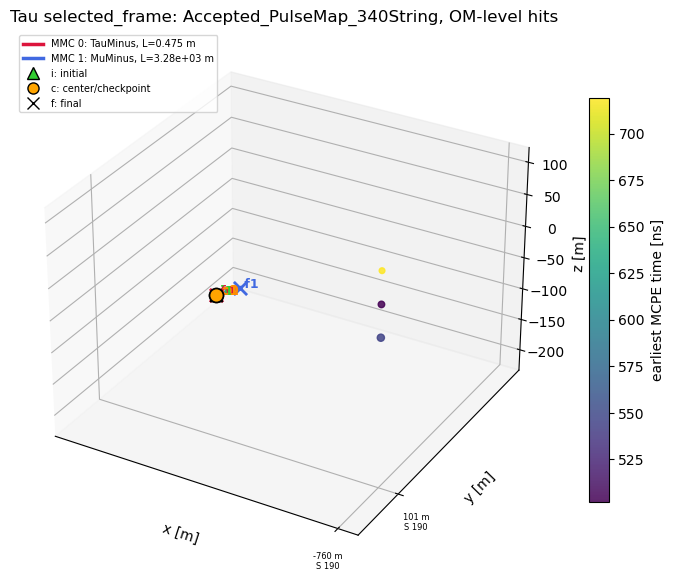

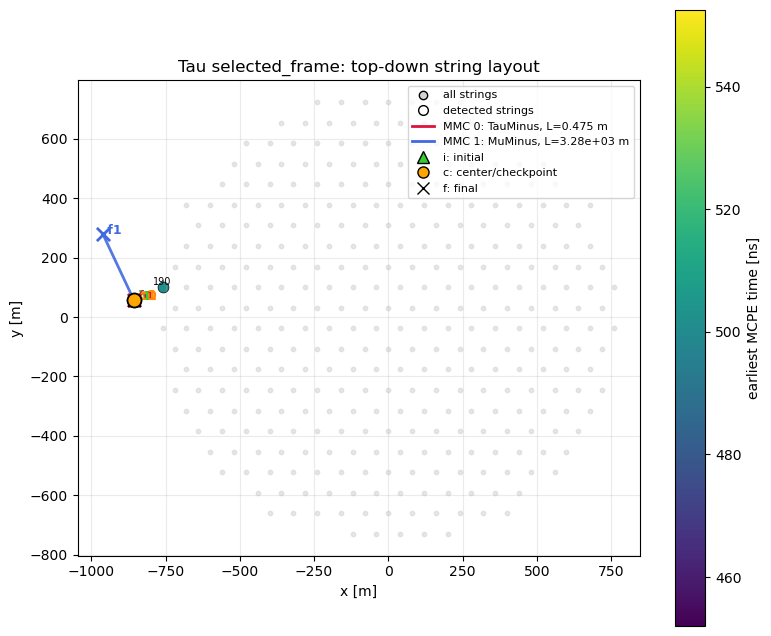

In [8]:
# Draw everything for the currently selected tau selected_frame.
# Run this right after the tau frame-selection cell.

from collections import defaultdict
from pathlib import Path
import csv

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

GCD_PATH = "/project/6008051/pone_simulation/GCD_Library/PONE_800mGrid.i3.gz"
STRING_COORDS_CSV = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Metadata/GeometryFiles/string_coordinates_340_string_mc.csv"
)


def read_geometry_frame(gcd_path):
    gcd_file = dataio.I3File(gcd_path, "r")
    while gcd_file.more():
        frame = gcd_file.pop_frame()
        if frame.Stop == frame.Geometry:
            gcd_file.close()
            return frame
    gcd_file.close()
    raise RuntimeError(f"No Geometry frame found in {gcd_path}")


def pe_charge(pe):
    if hasattr(pe, "npe"):
        return float(pe.npe)
    if hasattr(pe, "NPE"):
        return float(pe.NPE)
    return 1.0


def pe_time(pe):
    if hasattr(pe, "time"):
        return float(pe.time)
    return float(pe.Time)


TRACK_COLORS = ["crimson", "royalblue", "darkorange", "purple", "seagreen", "black"]


def mmc_track_segments(frame):
    segments = []
    for i, track in enumerate(frame["MMCTrackList"]):
        try:
            start = (float(track.xi), float(track.yi), float(track.zi))
            center = (float(track.xc), float(track.yc), float(track.zc))
            stop = (float(track.xf), float(track.yf), float(track.zf))
        except AttributeError:
            continue

        particle = getattr(track, "particle", None)
        particle_type = str(getattr(particle, "type", f"track_{i}"))
        length = float(getattr(particle, "length", 0.0)) if particle is not None else 0.0
        color = TRACK_COLORS[i % len(TRACK_COLORS)]
        segments.append({
            "index": i,
            "start": start,
            "center": center,
            "stop": stop,
            "color": color,
            "label": f"MMC {i}: {particle_type}, L={length:.3g} m",
        })
    return segments


def axis_ticks_with_string_ids(values, labels, max_ticks=3):
    value_to_strings = {}
    for value, label in zip(values, labels):
        key = round(value, 1)
        string = label.split(",")[0]
        value_to_strings.setdefault(key, set()).add(string)
    ticks = sorted(value_to_strings)
    if len(ticks) > max_ticks:
        idxs = [round(i * (len(ticks) - 1) / (max_ticks - 1)) for i in range(max_ticks)]
        ticks = [ticks[i] for i in idxs]
    tick_labels = [
        f"{tick:.0f} m\nS {','.join(sorted(value_to_strings[tick], key=int))}"
        for tick in ticks
    ]
    return ticks, tick_labels


if selected_frame is None:
    raise RuntimeError("No selected frame. Run the tau frame-selection cell first.")

geometry = read_geometry_frame(GCD_PATH)["I3Geometry"].omgeo
pulse_map = selected_frame["Accepted_PulseMap_340String"]

om_hits = defaultdict(lambda: {"x": [], "y": [], "z": [], "charge": 0.0, "time": None, "pmts": set()})

for omkey, pulses in pulse_map.items():
    if omkey not in geometry:
        continue

    pos = geometry[omkey].position
    om_id = (int(omkey.string), int(omkey.om))
    pmt = int(omkey.pmt) if hasattr(omkey, "pmt") else int(omkey.pmt_id)

    om_hits[om_id]["x"].append(float(pos.x))
    om_hits[om_id]["y"].append(float(pos.y))
    om_hits[om_id]["z"].append(float(pos.z))
    om_hits[om_id]["pmts"].add(pmt)

    for pe in pulses:
        q = pe_charge(pe)
        t = pe_time(pe)
        om_hits[om_id]["charge"] += q
        if om_hits[om_id]["time"] is None or t < om_hits[om_id]["time"]:
            om_hits[om_id]["time"] = t

xs, ys, zs, charges, times, labels = [], [], [], [], [], []
for (string, om), hit in sorted(om_hits.items()):
    if hit["charge"] <= 0 or hit["time"] is None:
        continue

    xs.append(sum(hit["x"]) / len(hit["x"]))
    ys.append(sum(hit["y"]) / len(hit["y"]))
    zs.append(sum(hit["z"]) / len(hit["z"]))
    charges.append(hit["charge"])
    times.append(hit["time"])
    labels.append(f"{string},{om} ({len(hit['pmts'])} PMTs)")

sizes = [12 + 5 * min(q, 10) for q in charges]
mmc_segments = mmc_track_segments(selected_frame)

print("selected file:", globals().get("selected_file", None))
print("selected frame index in file:", globals().get("selected_frame_index", None))
print("OM-level hits:", len(xs))
print("MMC tracks:", len(mmc_segments))

x_ticks, x_tick_labels = axis_ticks_with_string_ids(xs, labels, max_ticks=3)
y_ticks, y_tick_labels = axis_ticks_with_string_ids(ys, labels, max_ticks=3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(xs, ys, zs, c=times, s=sizes, cmap="viridis", alpha=0.85)

for seg in mmc_segments:
    idx = seg["index"]
    color = seg["color"]
    x0, y0, z0 = seg["start"]
    xc, yc, zc = seg["center"]
    x1, y1, z1 = seg["stop"]
    ax.plot([x0, x1], [y0, y1], [z0, z1], color=color, linewidth=2.5, label=seg["label"])
    ax.scatter([x0], [y0], [z0], marker="^", s=75, color="limegreen", edgecolor="black", linewidth=1.0, depthshade=False)
    ax.scatter([xc], [yc], [zc], marker="o", s=100, color="orange", edgecolor="black", linewidth=1.2, depthshade=False)
    ax.scatter([x1], [y1], [z1], marker="x", s=90, color=color, linewidth=2.0, depthshade=False)
    ax.text(x0, y0, z0, f" i{idx}", color="limegreen", fontsize=9, fontweight="bold")
    ax.text(xc, yc, zc, f" c{idx}", color="darkorange", fontsize=10, fontweight="bold")
    ax.text(x1, y1, z1, f" f{idx}", color=color, fontsize=9, fontweight="bold")

if mmc_segments:
    legend_handles = [
        Line2D([0], [0], color=seg["color"], lw=2.5, label=seg["label"])
        for seg in mmc_segments
    ]
    legend_handles += [
        Line2D([0], [0], marker="^", color="none", markerfacecolor="limegreen", markeredgecolor="black", markersize=8, label="i: initial"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="orange", markeredgecolor="black", markersize=8, label="c: center/checkpoint"),
        Line2D([0], [0], marker="x", color="black", markersize=8, linestyle="None", label="f: final"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=7)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels, fontsize=6)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels, fontsize=6)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("Tau selected_frame: Accepted_PulseMap_340String, OM-level hits")
fig.colorbar(sc, ax=ax, label="earliest MCPE time [ns]", shrink=0.75)
plt.tight_layout()
plt.show()

string_coords = {}
with STRING_COORDS_CSV.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        string_coords[int(row["string"])] = (float(row["x"]), float(row["y"]))

detected_strings = sorted({string for (string, om), hit in om_hits.items() if hit["charge"] > 0})
charge_by_string = {string: 0.0 for string in detected_strings}
time_by_string = {string: None for string in detected_strings}

for (string, om), hit in om_hits.items():
    if hit["charge"] <= 0:
        continue
    charge_by_string[string] = charge_by_string.get(string, 0.0) + hit["charge"]
    if time_by_string.get(string) is None or hit["time"] < time_by_string[string]:
        time_by_string[string] = hit["time"]

all_x = [xy[0] for xy in string_coords.values()]
all_y = [xy[1] for xy in string_coords.values()]

detected_in_csv = [string for string in detected_strings if string in string_coords]
det_x = [string_coords[string][0] for string in detected_in_csv]
det_y = [string_coords[string][1] for string in detected_in_csv]
det_t = [time_by_string[string] for string in detected_in_csv]
det_s = [25 + 6 * min(charge_by_string[string], 20) for string in detected_in_csv]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(all_x, all_y, s=10, color="lightgray", alpha=0.55, label="all strings")
sc = ax.scatter(
    det_x,
    det_y,
    s=det_s,
    c=det_t,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5,
    label="detected strings",
)

for string in detected_in_csv:
    x, y = string_coords[string]
    ax.text(x, y, str(string), fontsize=7, ha="center", va="bottom")

ax.set_title("Tau selected_frame: top-down string layout")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)

for seg in mmc_segments:
    idx = seg["index"]
    color = seg["color"]
    x0, y0, _ = seg["start"]
    xc, yc, _ = seg["center"]
    x1, y1, _ = seg["stop"]
    ax.plot([x0, x1], [y0, y1], color=color, linewidth=2.0, alpha=0.9)
    ax.scatter([x0], [y0], marker="^", s=75, color="limegreen", edgecolor="black", linewidth=1.0, zorder=5)
    ax.scatter([xc], [yc], marker="o", s=100, color="orange", edgecolor="black", linewidth=1.2, zorder=6)
    ax.scatter([x1], [y1], marker="x", s=90, color=color, linewidth=2.0, zorder=5)
    ax.text(x0, y0, f" i{idx}", color="limegreen", fontsize=9, fontweight="bold")
    ax.text(xc, yc, f" c{idx}", color="darkorange", fontsize=10, fontweight="bold")
    ax.text(x1, y1, f" f{idx}", color=color, fontsize=9, fontweight="bold")

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="lightgray", markersize=6, label="all strings"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black", markersize=7, label="detected strings"),
]
legend_handles += [
    Line2D([0], [0], color=seg["color"], lw=2.0, label=seg["label"])
    for seg in mmc_segments
]
legend_handles += [
    Line2D([0], [0], marker="^", color="none", markerfacecolor="limegreen", markeredgecolor="black", markersize=8, label="i: initial"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="orange", markeredgecolor="black", markersize=8, label="c: center/checkpoint"),
    Line2D([0], [0], marker="x", color="black", markersize=8, linestyle="None", label="f: final"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8)
fig.colorbar(sc, ax=ax, label="earliest MCPE time [ns]", shrink=0.8)
plt.tight_layout()
plt.show()




In [9]:
import numpy as np

for idx, track in enumerate(selected_frame["MMCTrackList"]):
    i = np.array([float(track.xi), float(track.yi), float(track.zi)])
    c = np.array([float(track.xc), float(track.yc), float(track.zc)])
    f = np.array([float(track.xf), float(track.yf), float(track.zf)])

    print(f"Track {idx}: {track.particle.type}")
    print("particle.length =", float(track.particle.length), "m")
    print("|f - i|         =", np.linalg.norm(f - i), "m")
    print("i =", i)
    print("c =", c)
    print("f =", f)
    print()

Track 0: TauMinus
particle.length = 0.47482019900232386 m
|f - i|         = 0.4748201990023421 m
i = [-857.32850183   58.1494669    46.25308487]
c = [-857.32850183   58.1494669    46.25308487]
f = [-857.46707053   58.44440028   45.90773398]

Track 1: MuMinus
particle.length = 3280.914927830693 m
|f - i|         = 353.3981209415629 m
i = [-857.46707053   58.44440028   45.90773398]
c = [-857.46707053   58.44440028   45.90773398]
f = [-960.59093419  277.9714308  -211.12063702]



# AcceptedPulse_Map Comparison for all flavors

In [ ]:
# Select the first event per flavor with 4250 <= E <= 4750 GeV and vertex within 500 m.
# This only selects frames. We will add the four 3D plots after checking the selected events.

import glob
import numpy as np

FLAVOR_DIRS = {
    "Muon": "/home/kbas/scratch/String340MC_pone_offline_version3/Muon_PMT_Response",
    "Electron": "/home/kbas/scratch/String340MC_pone_offline_version3/Electron_PMT_Response",
    "Tau": "/home/kbas/scratch/String340MC_pone_offline_version3/Tau_PMT_Response",
    "NC": "/home/kbas/scratch/String340MC_pone_offline_version3/NC_PMT_Response",
}

ENERGY_MIN = 9000.0
ENERGY_MAX = 10000.0
CENTER_XYZ = np.array([0.0, 0.0, 0.0])
MAX_VERTEX_R = 500.0

REQUIRED_KEYS = ["EventProperties", "triggered_340_string", "Accepted_PulseMap_340String"]


def get_attr(obj, names):
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name)
    return None


def event_energy(frame):
    return float(frame["EventProperties"].totalEnergy)


def event_vertex(frame):
    ep = frame["EventProperties"]
    x = get_attr(ep, ["x", "posX", "vertexX", "injectionX"])
    y = get_attr(ep, ["y", "posY", "vertexY", "injectionY"])
    z = get_attr(ep, ["z", "posZ", "vertexZ", "injectionZ"])

    if x is not None and y is not None and z is not None:
        return np.array([float(x), float(y), float(z)]), "EventProperties"

    for key in ["MCPrimary", "I3MCTree"]:
        if key not in frame:
            continue
        obj = frame[key]
        particle = None
        if key == "MCPrimary":
            particle = obj
        else:
            try:
                particle = obj.primaries[0]
            except Exception:
                try:
                    particle = list(obj)[0]
                except Exception:
                    particle = None
        if particle is None:
            continue
        pos = getattr(particle, "pos", None)
        if pos is not None:
            return np.array([float(pos.x), float(pos.y), float(pos.z)]), key

    return None, None


def frame_passes_basic_cuts(frame):
    for key in REQUIRED_KEYS:
        if key not in frame:
            return False
    if float(frame["triggered_340_string"].value) != 1:
        return False
    return True


def find_first_frame(flavor, directory):
    files = sorted(glob.glob(f"{directory}/*.i3.gz"))
    global_frame_index = 0

    for file_index, path_i3 in enumerate(files):
        i3_file = dataio.I3File(path_i3, "r")
        frame_index = 0

        while i3_file.more():
            frame = i3_file.pop_frame()
            frame_index += 1
            global_frame_index += 1

            if not frame_passes_basic_cuts(frame):
                continue

            energy = event_energy(frame)
            if not (ENERGY_MIN <= energy <= ENERGY_MAX):
                continue

            vertex, vertex_source = event_vertex(frame)
            if vertex is None:
                continue

            vertex_r = float(np.linalg.norm(vertex - CENTER_XYZ))
            if vertex_r > MAX_VERTEX_R:
                continue

            result = {
                "flavor": flavor,
                "frame": frame,
                "file": path_i3,
                "file_index": file_index,
                "frame_index": frame_index,
                "global_frame_index": global_frame_index,
                "energy": energy,
                "vertex": vertex,
                "vertex_r": vertex_r,
                "vertex_source": vertex_source,
                "n_mmc_tracks": len(frame["MMCTrackList"]) if "MMCTrackList" in frame else None,
            }
            i3_file.close()
            return result

        i3_file.close()

    return None


selected_flavor_frames = {}

for flavor, directory in FLAVOR_DIRS.items():
    selected = find_first_frame(flavor, directory)
    selected_flavor_frames[flavor] = selected

    if selected is None:
        print(f"{flavor}: no frame found with {ENERGY_MIN} <= E <= {ENERGY_MAX} and vertex r <= {MAX_VERTEX_R} m")
        continue

    print(f"Selected {flavor}:")
    print("  file:", selected["file"])
    print("  frame index:", selected["frame_index"])
    print("  global frame index:", selected["global_frame_index"])
    print("  energy:", selected["energy"])
    print("  vertex:", selected["vertex"], "r=", selected["vertex_r"])
    print("  vertex source:", selected["vertex_source"])
    print("  n MMC tracks:", selected["n_mmc_tracks"])
    print()

muon_frame = selected_flavor_frames["Muon"]["frame"] if selected_flavor_frames.get("Muon") else None
electron_frame = selected_flavor_frames["Electron"]["frame"] if selected_flavor_frames.get("Electron") else None
tau_frame = selected_flavor_frames["Tau"]["frame"] if selected_flavor_frames.get("Tau") else None
nc_frame = selected_flavor_frames["NC"]["frame"] if selected_flavor_frames.get("NC") else None



Selected Muon:
  file: /home/kbas/scratch/String340MC_pone_offline_version3/Muon_PMT_Response/muon_cls_1048.i3.gz
  frame index: 136
  global frame index: 29590
  energy: 9175.326959229304
  vertex: [ 273.1557094   127.13299482 -146.3391862 ] r= 334.9507387166983
  vertex source: EventProperties
  n MMC tracks: 1



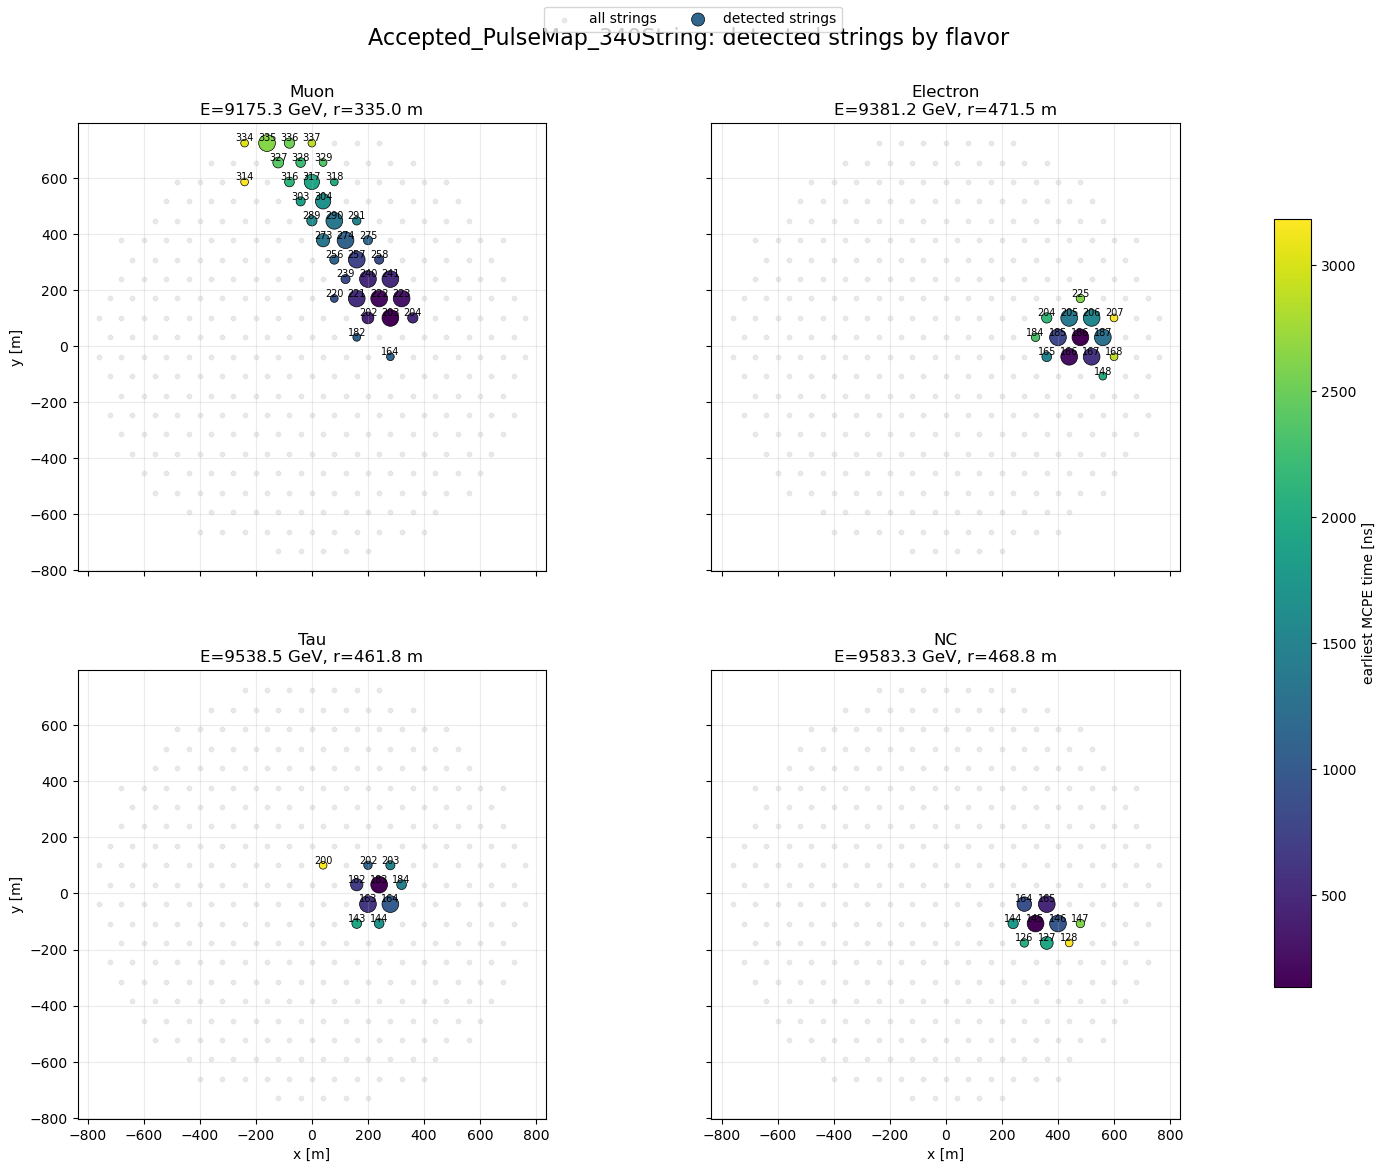

In [12]:
from collections import defaultdict
from pathlib import Path
import csv

import matplotlib.pyplot as plt

STRING_COORDS_CSV = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Metadata/GeometryFiles/string_coordinates_340_string_mc.csv"
)

frames_to_plot = {
    "Muon": muon_frame,
    "Electron": electron_frame,
    "Tau": tau_frame,
    "NC": nc_frame,
}

string_coords = {}
with STRING_COORDS_CSV.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        string_coords[int(row["string"])] = (float(row["x"]), float(row["y"]))

all_x = [xy[0] for xy in string_coords.values()]
all_y = [xy[1] for xy in string_coords.values()]


def pe_charge(pe):
    if hasattr(pe, "npe"):
        return float(pe.npe)
    if hasattr(pe, "NPE"):
        return float(pe.NPE)
    return 1.0


def pe_time(pe):
    if hasattr(pe, "time"):
        return float(pe.time)
    return float(pe.Time)


def pulsemap_to_string_hits(frame):
    pulse_map = frame["Accepted_PulseMap_340String"]

    charge_by_string = defaultdict(float)
    time_by_string = {}

    for omkey, pulses in pulse_map.items():
        string = int(omkey.string)

        for pe in pulses:
            charge_by_string[string] += pe_charge(pe)
            t = pe_time(pe)

            if string not in time_by_string or t < time_by_string[string]:
                time_by_string[string] = t

    detected_strings = sorted(
        string for string in charge_by_string
        if charge_by_string[string] > 0 and string in string_coords
    )

    det_x = [string_coords[string][0] for string in detected_strings]
    det_y = [string_coords[string][1] for string in detected_strings]
    det_t = [time_by_string[string] for string in detected_strings]
    det_s = [25 + 6 * min(charge_by_string[string], 20) for string in detected_strings]

    return detected_strings, det_x, det_y, det_t, det_s


fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.ravel()

all_mappables = []

for ax, (flavor, frame) in zip(axes, frames_to_plot.items()):
    ax.scatter(
        all_x,
        all_y,
        s=10,
        color="lightgray",
        alpha=0.45,
        label="all strings",
    )

    if frame is None:
        ax.set_title(f"{flavor}: no selected frame")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.25)
        continue

    detected_strings, det_x, det_y, det_t, det_s = pulsemap_to_string_hits(frame)

    sc = ax.scatter(
        det_x,
        det_y,
        s=det_s,
        c=det_t,
        cmap="viridis",
        edgecolor="black",
        linewidth=0.5,
        label="detected strings",
    )
    all_mappables.append(sc)

    for string, x, y in zip(detected_strings, det_x, det_y):
        ax.text(x, y, str(string), fontsize=7, ha="center", va="bottom")

    info = selected_flavor_frames.get(flavor)
    if info is not None:
        title = (
            f"{flavor}\n"
            f"E={info['energy']:.1f} GeV, "
            f"r={info['vertex_r']:.1f} m"
        )
    else:
        title = flavor

    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

for ax in axes[::2]:
    ax.set_ylabel("y [m]")

for ax in axes[2:]:
    ax.set_xlabel("x [m]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle("Accepted_PulseMap_340String: detected strings by flavor", fontsize=16)

fig.subplots_adjust(
    left=0.06,
    right=0.86,
    bottom=0.07,
    top=0.90,
    wspace=0.12,
    hspace=0.22,
)

if all_mappables:
    cbar_ax = fig.add_axes([0.89, 0.18, 0.025, 0.64])
    fig.colorbar(
        all_mappables[0],
        cax=cbar_ax,
        label="earliest MCPE time [ns]",
    )
output_png = Path("/project/def-nahee/kbas/Graphnet-Applications/Playground/String340MC/accepted_pulsemap_340string_by_flavor.png")
fig.savefig(output_png, dpi=300, bbox_inches="tight")

plt.show()

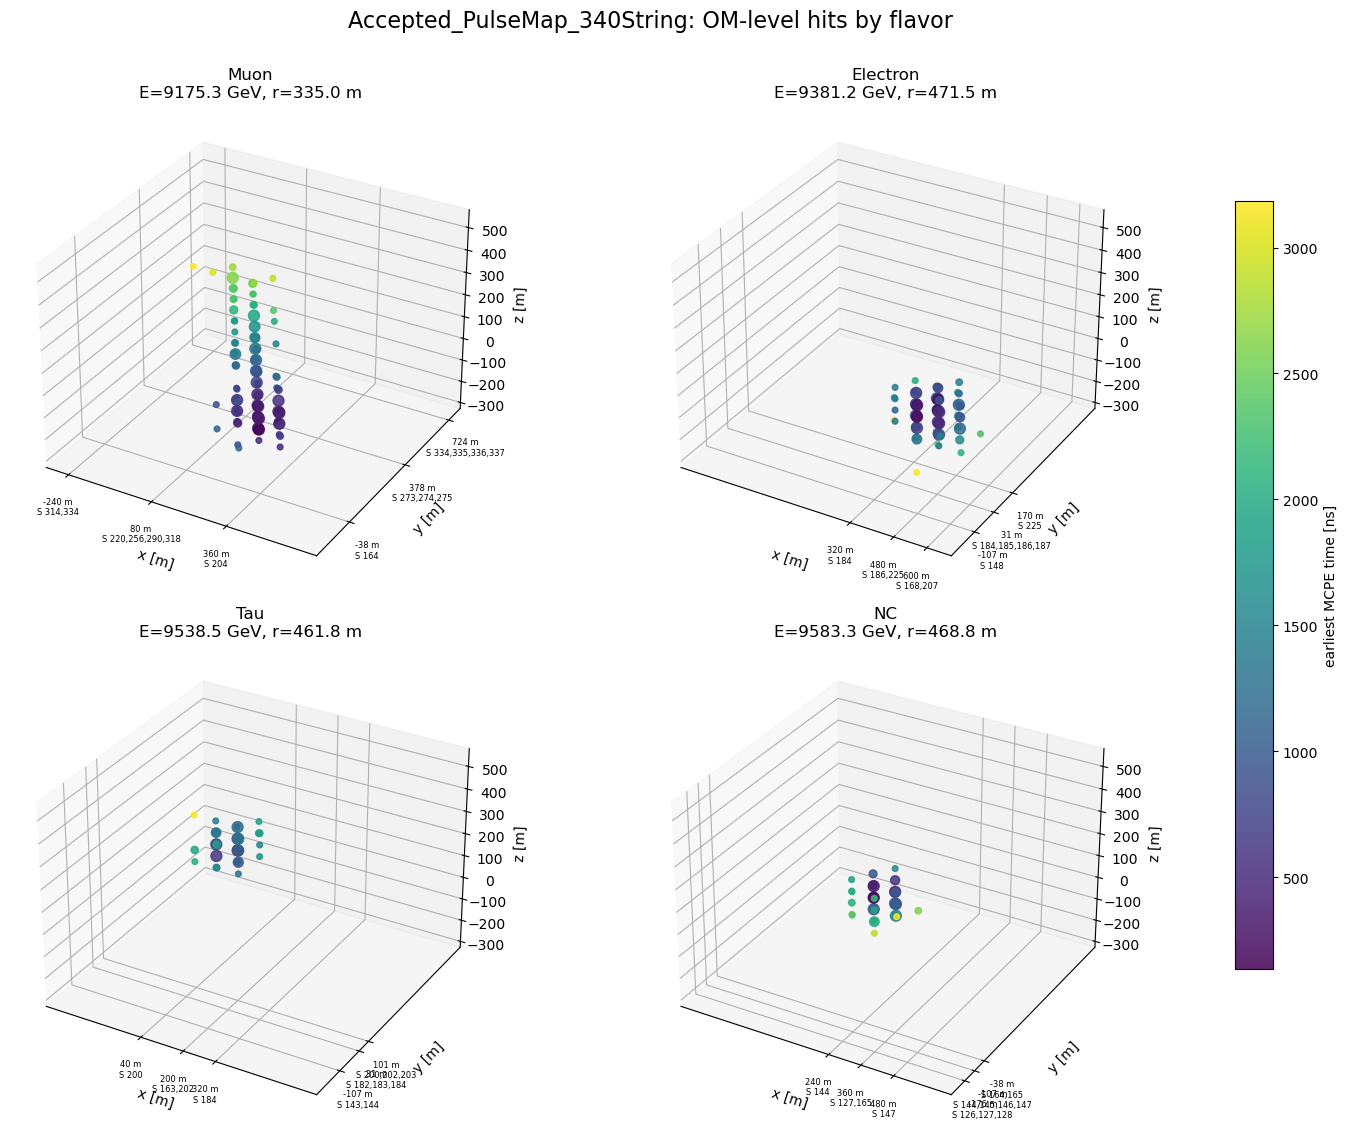

In [13]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

GCD_PATH = "/project/6008051/pone_simulation/GCD_Library/PONE_800mGrid.i3.gz"

frames_to_plot = {
    "Muon": muon_frame,
    "Electron": electron_frame,
    "Tau": tau_frame,
    "NC": nc_frame,
}


def read_geometry_frame(gcd_path):
    gcd_file = dataio.I3File(gcd_path, "r")
    while gcd_file.more():
        frame = gcd_file.pop_frame()
        if frame.Stop == frame.Geometry:
            gcd_file.close()
            return frame
    gcd_file.close()
    raise RuntimeError(f"No Geometry frame found in {gcd_path}")


def pe_charge(pe):
    if hasattr(pe, "npe"):
        return float(pe.npe)
    if hasattr(pe, "NPE"):
        return float(pe.NPE)
    return 1.0


def pe_time(pe):
    if hasattr(pe, "time"):
        return float(pe.time)
    return float(pe.Time)


def frame_to_om_hits(frame, geometry):
    pulse_map = frame["Accepted_PulseMap_340String"]

    om_hits = defaultdict(lambda: {"x": [], "y": [], "z": [], "charge": 0.0, "time": None, "pmts": set()})

    for omkey, pulses in pulse_map.items():
        if omkey not in geometry:
            continue

        pos = geometry[omkey].position
        om_id = (int(omkey.string), int(omkey.om))
        pmt = int(omkey.pmt) if hasattr(omkey, "pmt") else int(omkey.pmt_id)

        om_hits[om_id]["x"].append(float(pos.x))
        om_hits[om_id]["y"].append(float(pos.y))
        om_hits[om_id]["z"].append(float(pos.z))
        om_hits[om_id]["pmts"].add(pmt)

        for pe in pulses:
            q = pe_charge(pe)
            t = pe_time(pe)

            om_hits[om_id]["charge"] += q
            if om_hits[om_id]["time"] is None or t < om_hits[om_id]["time"]:
                om_hits[om_id]["time"] = t

    xs, ys, zs, charges, times, labels = [], [], [], [], [], []

    for (string, om), hit in sorted(om_hits.items()):
        if hit["charge"] <= 0 or hit["time"] is None:
            continue

        xs.append(sum(hit["x"]) / len(hit["x"]))
        ys.append(sum(hit["y"]) / len(hit["y"]))
        zs.append(sum(hit["z"]) / len(hit["z"]))
        charges.append(hit["charge"])
        times.append(hit["time"])
        labels.append(f"{string},{om} ({len(hit['pmts'])} PMTs)")

    sizes = [12 + 5 * min(q, 10) for q in charges]

    return xs, ys, zs, charges, times, labels, sizes


def axis_ticks_with_string_ids(values, labels, max_ticks=3):
    value_to_strings = {}

    for value, label in zip(values, labels):
        key = round(value, 1)
        string = label.split(",")[0]
        value_to_strings.setdefault(key, set()).add(string)

    ticks = sorted(value_to_strings)

    if len(ticks) > max_ticks:
        idxs = [round(i * (len(ticks) - 1) / (max_ticks - 1)) for i in range(max_ticks)]
        ticks = [ticks[i] for i in idxs]

    tick_labels = [
        f"{tick:.0f} m\nS {','.join(sorted(value_to_strings[tick], key=int))}"
        for tick in ticks
    ]

    return ticks, tick_labels


def padded_limits(values, pad_fraction=0.08):
    vmin = min(values)
    vmax = max(values)
    pad = pad_fraction * (vmax - vmin)

    if pad == 0:
        pad = 1.0

    return vmin - pad, vmax + pad


geometry = read_geometry_frame(GCD_PATH)["I3Geometry"].omgeo

plot_data = {}
all_xs, all_ys, all_zs = [], [], []

for flavor, frame in frames_to_plot.items():
    if frame is None:
        plot_data[flavor] = None
        continue

    data = frame_to_om_hits(frame, geometry)
    plot_data[flavor] = data

    xs, ys, zs, charges, times, labels, sizes = data
    all_xs.extend(xs)
    all_ys.extend(ys)
    all_zs.extend(zs)

if not all_xs or not all_ys or not all_zs:
    raise RuntimeError("No OM-level hits found in selected frames.")

xlim = padded_limits(all_xs)
ylim = padded_limits(all_ys)
zlim = padded_limits(all_zs)

fig = plt.figure(figsize=(15, 12))
axes = [
    fig.add_subplot(2, 2, 1, projection="3d"),
    fig.add_subplot(2, 2, 2, projection="3d"),
    fig.add_subplot(2, 2, 3, projection="3d"),
    fig.add_subplot(2, 2, 4, projection="3d"),
]

all_mappables = []

for ax, (flavor, frame) in zip(axes, frames_to_plot.items()):
    if frame is None or plot_data[flavor] is None:
        ax.set_title(f"{flavor}: no selected frame")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_zlim(zlim)
        continue

    xs, ys, zs, charges, times, labels, sizes = plot_data[flavor]

    sc = ax.scatter(
        xs,
        ys,
        zs,
        c=times,
        s=sizes,
        cmap="viridis",
        alpha=0.85,
        depthshade=True,
    )
    all_mappables.append(sc)

    x_ticks, x_tick_labels = axis_ticks_with_string_ids(xs, labels, max_ticks=3)
    y_ticks, y_tick_labels = axis_ticks_with_string_ids(ys, labels, max_ticks=3)

    info = selected_flavor_frames.get(flavor)
    if info is not None:
        title = (
            f"{flavor}\n"
            f"E={info['energy']:.1f} GeV, "
            f"r={info['vertex_r']:.1f} m"
        )
    else:
        title = flavor

    ax.set_title(title)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_tick_labels, fontsize=6)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels, fontsize=6)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)

fig.suptitle("Accepted_PulseMap_340String: OM-level hits by flavor", fontsize=16)

fig.subplots_adjust(
    left=0.03,
    right=0.86,
    bottom=0.05,
    top=0.90,
    wspace=0.04,
    hspace=0.12,
)

if all_mappables:
    cbar_ax = fig.add_axes([0.89, 0.18, 0.025, 0.64])
    fig.colorbar(
        all_mappables[0],
        cax=cbar_ax,
        label="earliest MCPE time [ns]",
    )

plt.show()

In [ ]:
from collections import defaultdict
from pathlib import Path

from matplotlib import animation
from matplotlib.animation import PillowWriter
import matplotlib.pyplot as plt
import numpy as np

GCD_PATH = "/project/6008051/pone_simulation/GCD_Library/PONE_800mGrid.i3.gz"
OUTPUT_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Playground/String340MC")

frames_to_plot = {
    "Muon": muon_frame,
    "Electron": electron_frame,
    "Tau": tau_frame,
    "NC": nc_frame,
}


def read_geometry_frame(gcd_path):
    gcd_file = dataio.I3File(gcd_path, "r")
    while gcd_file.more():
        frame = gcd_file.pop_frame()
        if frame.Stop == frame.Geometry:
            gcd_file.close()
            return frame
    gcd_file.close()
    raise RuntimeError(f"No Geometry frame found in {gcd_path}")


def pe_time(pe):
    if hasattr(pe, "time"):
        return float(pe.time)
    return float(pe.Time)


def frame_to_om_hits(frame, geometry):
    pulse_map = frame["Accepted_PulseMap_340String"]

    om_hits = defaultdict(lambda: {"x": [], "y": [], "z": [], "pulse_count": 0, "time": None})

    for omkey, pulses in pulse_map.items():
        if omkey not in geometry:
            continue

        pos = geometry[omkey].position
        om_id = (int(omkey.string), int(omkey.om))

        om_hits[om_id]["x"].append(float(pos.x))
        om_hits[om_id]["y"].append(float(pos.y))
        om_hits[om_id]["z"].append(float(pos.z))
        om_hits[om_id]["pulse_count"] += len(pulses)

        for pe in pulses:
            t = pe_time(pe)
            if om_hits[om_id]["time"] is None or t < om_hits[om_id]["time"]:
                om_hits[om_id]["time"] = t

    xs, ys, zs, pulse_counts, times = [], [], [], [], []

    for hit in om_hits.values():
        if hit["pulse_count"] <= 0 or hit["time"] is None:
            continue

        xs.append(sum(hit["x"]) / len(hit["x"]))
        ys.append(sum(hit["y"]) / len(hit["y"]))
        zs.append(sum(hit["z"]) / len(hit["z"]))
        pulse_counts.append(hit["pulse_count"])
        times.append(hit["time"])

    sizes = [18 + 8 * min(n, 20) for n in pulse_counts]

    return xs, ys, zs, pulse_counts, times, sizes


def common_equal_limits(all_xs, all_ys, all_zs, pad_fraction=0.08):
    xmin, xmax = min(all_xs), max(all_xs)
    ymin, ymax = min(all_ys), max(all_ys)
    zmin, zmax = min(all_zs), max(all_zs)

    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)
    zmid = 0.5 * (zmin + zmax)

    span = max(xmax - xmin, ymax - ymin, zmax - zmin)
    span = span * (1 + pad_fraction)

    if span == 0:
        span = 1.0

    half = 0.5 * span

    return (
        (xmid - half, xmid + half),
        (ymid - half, ymid + half),
        (zmid - half, zmid + half),
    )


def clean_3d_axes(ax):
    ax.grid(False)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.set_alpha(0.0)
        axis.pane.set_edgecolor("white")
        axis._axinfo["grid"]["linewidth"] = 0
        axis._axinfo["grid"]["color"] = (1, 1, 1, 0)

    ax.set_proj_type("ortho")


geometry = read_geometry_frame(GCD_PATH)["I3Geometry"].omgeo

plot_data = {}
all_xs, all_ys, all_zs = [], [], []

for flavor, frame in frames_to_plot.items():
    if frame is None:
        plot_data[flavor] = None
        continue

    data = frame_to_om_hits(frame, geometry)
    plot_data[flavor] = data

    xs, ys, zs, pulse_counts, times, sizes = data
    all_xs.extend(xs)
    all_ys.extend(ys)
    all_zs.extend(zs)

if not all_xs or not all_ys or not all_zs:
    raise RuntimeError("No OM-level hits found in selected frames.")

xlim, ylim, zlim = common_equal_limits(all_xs, all_ys, all_zs)

n_ticks = 5
x_ticks = np.linspace(xlim[0], xlim[1], n_ticks)
y_ticks = np.linspace(ylim[0], ylim[1], n_ticks)
z_ticks = np.linspace(zlim[0], zlim[1], n_ticks)

fig = plt.figure(figsize=(15, 12))
axes = [
    fig.add_subplot(2, 2, 1, projection="3d"),
    fig.add_subplot(2, 2, 2, projection="3d"),
    fig.add_subplot(2, 2, 3, projection="3d"),
    fig.add_subplot(2, 2, 4, projection="3d"),
]

all_mappables = []

for ax, (flavor, frame) in zip(axes, frames_to_plot.items()):
    clean_3d_axes(ax)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)
    ax.set_box_aspect((1, 1, 1))

    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_zticks(z_ticks)

    ax.set_xticklabels([f"{x:.0f}" for x in x_ticks], fontsize=6)
    ax.set_yticklabels([f"{y:.0f}" for y in y_ticks], fontsize=6)
    ax.set_zticklabels([f"{z:.0f}" for z in z_ticks], fontsize=6)

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    if frame is None or plot_data[flavor] is None:
        ax.set_title(f"{flavor}: no selected frame")
        continue

    xs, ys, zs, pulse_counts, times, sizes = plot_data[flavor]

    sc = ax.scatter(
        xs,
        ys,
        zs,
        c=times,
        s=sizes,
        cmap="viridis",
        marker="o",
        alpha=0.9,
        depthshade=True,
        edgecolors="black",
        linewidths=0.25,
    )
    all_mappables.append(sc)

    info = selected_flavor_frames.get(flavor)
    if info is not None:
        title = (
            f"{flavor}\n"
            f"E={info['energy']:.1f} GeV, "
            f"r={info['vertex_r']:.1f} m"
        )
    else:
        title = flavor

    ax.set_title(title)
    ax.view_init(elev=8, azim=-90)

fig.suptitle(
    "Accepted_PulseMap_340String: OM-level hits by flavor - size = pulse count",
    fontsize=16,
)

fig.subplots_adjust(
    left=0.03,
    right=0.86,
    bottom=0.05,
    top=0.90,
    wspace=0.04,
    hspace=0.12,
)

if all_mappables:
    cbar_ax = fig.add_axes([0.89, 0.18, 0.025, 0.64])
    fig.colorbar(
        all_mappables[0],
        cax=cbar_ax,
        label="earliest MCPE time [ns]",
    )


def update(angle):
    for ax in axes:
        ax.view_init(elev=8, azim=angle)
    return tuple(all_mappables)


ani = animation.FuncAnimation(
    fig,
    update,
    frames=range(-90, 270, 3),
    interval=70,
    blit=False,
)

gif_path = OUTPUT_DIR / "accepted_pulsemap_4flavor_rotating_pulsecount_size_clean_equal_axes.gif"

writer = PillowWriter(fps=15)
ani.save(gif_path, writer=writer, dpi=120)

plt.close(fig)
print("saved:", gif_path)

saved: /project/def-nahee/kbas/Graphnet-Applications/Playground/String340MC/accepted_pulsemap_4flavor_rotating_pulsecount_size_clean_equal_axes.gif


In [ ]:
from collections import defaultdict
from pathlib import Path

from matplotlib import animation
from matplotlib.animation import PillowWriter
import matplotlib.pyplot as plt
import numpy as np

GCD_PATH = "/project/6008051/pone_simulation/GCD_Library/PONE_800mGrid.i3.gz"
OUTPUT_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Playground/String340MC")

frames_to_plot = {
    "Muon": muon_frame,
    "Electron": electron_frame,
    "Tau": tau_frame,
    "NC": nc_frame,
}

DRAW_MMC_FOR = {"Muon", "Tau"}
TRACK_COLORS = ["crimson", "royalblue", "darkorange", "purple", "seagreen", "black"]


def read_geometry_frame(gcd_path):
    gcd_file = dataio.I3File(gcd_path, "r")
    while gcd_file.more():
        frame = gcd_file.pop_frame()
        if frame.Stop == frame.Geometry:
            gcd_file.close()
            return frame
    gcd_file.close()
    raise RuntimeError(f"No Geometry frame found in {gcd_path}")


def pe_time(pe):
    if hasattr(pe, "time"):
        return float(pe.time)
    return float(pe.Time)


def frame_to_om_hits(frame, geometry):
    pulse_map = frame["Accepted_PulseMap_340String"]

    om_hits = defaultdict(lambda: {"x": [], "y": [], "z": [], "pulse_count": 0, "time": None})

    for omkey, pulses in pulse_map.items():
        if omkey not in geometry:
            continue

        pos = geometry[omkey].position
        om_id = (int(omkey.string), int(omkey.om))

        om_hits[om_id]["x"].append(float(pos.x))
        om_hits[om_id]["y"].append(float(pos.y))
        om_hits[om_id]["z"].append(float(pos.z))
        om_hits[om_id]["pulse_count"] += len(pulses)

        for pe in pulses:
            t = pe_time(pe)
            if om_hits[om_id]["time"] is None or t < om_hits[om_id]["time"]:
                om_hits[om_id]["time"] = t

    xs, ys, zs, pulse_counts, times = [], [], [], [], []

    for hit in om_hits.values():
        if hit["pulse_count"] <= 0 or hit["time"] is None:
            continue

        xs.append(sum(hit["x"]) / len(hit["x"]))
        ys.append(sum(hit["y"]) / len(hit["y"]))
        zs.append(sum(hit["z"]) / len(hit["z"]))
        pulse_counts.append(hit["pulse_count"])
        times.append(hit["time"])

    sizes = [18 + 8 * min(n, 20) for n in pulse_counts]

    return xs, ys, zs, pulse_counts, times, sizes


def mmc_xi_xf_segments(frame):
    if "MMCTrackList" not in frame:
        return []

    segments = []

    for idx, track in enumerate(frame["MMCTrackList"]):
        try:
            xi = (float(track.xi), float(track.yi), float(track.zi))
            xf = (float(track.xf), float(track.yf), float(track.zf))
        except AttributeError:
            continue

        particle = getattr(track, "particle", None)
        particle_type = str(getattr(particle, "type", f"track_{idx}"))

        segments.append({
            "index": idx,
            "xi": xi,
            "xf": xf,
            "color": TRACK_COLORS[idx % len(TRACK_COLORS)],
            "label": f"MMC {idx}: {particle_type}",
        })

    return segments


def common_equal_limits(all_xs, all_ys, all_zs, pad_fraction=0.08):
    xmin, xmax = min(all_xs), max(all_xs)
    ymin, ymax = min(all_ys), max(all_ys)
    zmin, zmax = min(all_zs), max(all_zs)

    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)
    zmid = 0.5 * (zmin + zmax)

    span = max(xmax - xmin, ymax - ymin, zmax - zmin)
    span = span * (1 + pad_fraction)

    if span == 0:
        span = 1.0

    half = 0.5 * span

    return (
        (xmid - half, xmid + half),
        (ymid - half, ymid + half),
        (zmid - half, zmid + half),
    )


def clean_3d_axes(ax):
    ax.grid(False)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.set_alpha(0.0)
        axis.pane.set_edgecolor("white")
        axis._axinfo["grid"]["linewidth"] = 0
        axis._axinfo["grid"]["color"] = (1, 1, 1, 0)

    ax.set_proj_type("ortho")


geometry = read_geometry_frame(GCD_PATH)["I3Geometry"].omgeo

plot_data = {}
track_data = {}
all_xs, all_ys, all_zs = [], [], []

for flavor, frame in frames_to_plot.items():
    if frame is None:
        plot_data[flavor] = None
        track_data[flavor] = []
        continue

    data = frame_to_om_hits(frame, geometry)
    plot_data[flavor] = data

    xs, ys, zs, pulse_counts, times, sizes = data
    all_xs.extend(xs)
    all_ys.extend(ys)
    all_zs.extend(zs)

    if flavor in DRAW_MMC_FOR:
        segments = mmc_xi_xf_segments(frame)
    else:
        segments = []

    track_data[flavor] = segments

    for seg in segments:
        x0, y0, z0 = seg["xi"]
        x1, y1, z1 = seg["xf"]
        all_xs.extend([x0, x1])
        all_ys.extend([y0, y1])
        all_zs.extend([z0, z1])

if not all_xs or not all_ys or not all_zs:
    raise RuntimeError("No OM-level hits found in selected frames.")

xlim, ylim, zlim = common_equal_limits(all_xs, all_ys, all_zs)

n_ticks = 5
x_ticks = np.linspace(xlim[0], xlim[1], n_ticks)
y_ticks = np.linspace(ylim[0], ylim[1], n_ticks)
z_ticks = np.linspace(zlim[0], zlim[1], n_ticks)

fig = plt.figure(figsize=(15, 12))
axes = [
    fig.add_subplot(2, 2, 1, projection="3d"),
    fig.add_subplot(2, 2, 2, projection="3d"),
    fig.add_subplot(2, 2, 3, projection="3d"),
    fig.add_subplot(2, 2, 4, projection="3d"),
]

all_mappables = []

for ax, (flavor, frame) in zip(axes, frames_to_plot.items()):
    clean_3d_axes(ax)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)
    ax.set_box_aspect((1, 1, 1))

    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_zticks(z_ticks)

    ax.set_xticklabels([f"{x:.0f}" for x in x_ticks], fontsize=6)
    ax.set_yticklabels([f"{y:.0f}" for y in y_ticks], fontsize=6)
    ax.set_zticklabels([f"{z:.0f}" for z in z_ticks], fontsize=6)

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    if frame is None or plot_data[flavor] is None:
        ax.set_title(f"{flavor}: no selected frame")
        continue

    xs, ys, zs, pulse_counts, times, sizes = plot_data[flavor]

    sc = ax.scatter(
        xs,
        ys,
        zs,
        c=times,
        s=sizes,
        cmap="viridis",
        marker="o",
        alpha=0.9,
        depthshade=True,
        edgecolors="black",
        linewidths=0.25,
    )
    all_mappables.append(sc)

    for seg in track_data[flavor]:
        x0, y0, z0 = seg["xi"]
        x1, y1, z1 = seg["xf"]
        color = seg["color"]

        ax.plot(
            [x0, x1],
            [y0, y1],
            [z0, z1],
            color=color,
            linewidth=2.5,
            alpha=0.95,
            label=seg["label"],
        )
        ax.scatter([x0], [y0], [z0], marker="^", s=70, color=color, edgecolor="black", depthshade=False)
        ax.scatter([x1], [y1], [z1], marker="x", s=80, color=color, linewidth=2.0, depthshade=False)

    if track_data[flavor]:
        ax.legend(loc="upper left", fontsize=7)

    info = selected_flavor_frames.get(flavor)
    if info is not None:
        title = (
            f"{flavor}\n"
            f"E={info['energy']:.1f} GeV, "
            f"r={info['vertex_r']:.1f} m"
        )
    else:
        title = flavor

    ax.set_title(title)
    ax.view_init(elev=8, azim=-90)

fig.suptitle(
    "Accepted_PulseMap_340String: OM-level hits by flavor - Muon/Tau MMC xi->xf",
    fontsize=16,
)

fig.subplots_adjust(
    left=0.03,
    right=0.86,
    bottom=0.05,
    top=0.90,
    wspace=0.04,
    hspace=0.12,
)

if all_mappables:
    cbar_ax = fig.add_axes([0.89, 0.18, 0.025, 0.64])
    fig.colorbar(
        all_mappables[0],
        cax=cbar_ax,
        label="earliest MCPE time [ns]",
    )


def update(angle):
    for ax in axes:
        ax.view_init(elev=8, azim=angle)
    return tuple(all_mappables)


ani = animation.FuncAnimation(
    fig,
    update,
    frames=range(-90, 270, 3),
    interval=70,
    blit=False,
)

gif_path = OUTPUT_DIR / "accepted_pulsemap_4flavor_rotating_pulsecount_size_clean_equal_axes_mmc_xi_xf.gif"

writer = PillowWriter(fps=15)
ani.save(gif_path, writer=writer, dpi=120)

plt.close(fig)
print("saved:", gif_path)

saved: /project/def-nahee/kbas/Graphnet-Applications/Playground/String340MC/accepted_pulsemap_4flavor_rotating_pulsecount_size_clean_equal_axes_mmc_xi_xf.gif


In [ ]:
def find_best_double_bang(directory, energy_min=90000, min_decay_length=40.0):
    files = sorted(glob.glob(f"{directory}/*.i3.gz"))
    candidates = []
    
    for path in files:
        i3_file = dataio.I3File(path, "r")
        while i3_file.more():
            frame = i3_file.pop_frame()
            if "EventProperties" not in frame:
                continue
            if not is_double_bang(frame):
                continue
            
            ep = frame["EventProperties"]
            energy = float(ep.totalEnergy)
            if energy < energy_min:
                continue
            
            tree = frame["I3MCTree_postprop"]
            tau = None
            for p in tree:
                if p.type in [dataclasses.I3Particle.ParticleType.TauMinus,
                               dataclasses.I3Particle.ParticleType.TauPlus]:
                    tau = p
                    break
            if tau is None:
                continue
            
            decay_length = tau.length
            if decay_length < min_decay_length:
                continue
            
            candidates.append((energy, decay_length, frame, path))
        
        i3_file.close()
    
    candidates.sort(key=lambda x: x[1], reverse=True)  # en uzun decay length önce
    for e, l, _, p in candidates[:5]:
        print(f"E={e:.0f} GeV, decay_length={l:.1f} m, file={p}")
    
    return candidates[0][2] if candidates else None

tau_best_db_frame = find_best_double_bang(TAU_DIR)

KeyboardInterrupt: 

In [ ]:
EventProperties

In [ ]:
print(tau_db_frame["EventProperties"])

[ BasicEventProperties 
         TotalEnergy : 456783
              Zenith : 0.439884
             Azimuth : 6.18359
         FinalStateX : 0.001404
         FinalStateY : 0.657032
          FinalType1 : TauMinus
          FinalType2 : Hadrons
         InitialType : NuTau
                   X : -114.901
                   Y : 803.102
                   Z : -1018.64
    TotalColumnDepth : 462236
              Radius : 811.28
     ImpactParameter : 828.896
]


In [ ]:
from icecube import dataio, dataclasses

TARGET_EVENT = 107
path = f"{TAU_DIR}/tau_gen_052.i3.gz"

found_frame = None
i3_file = dataio.I3File(path, "r")
while i3_file.more():
    frame = i3_file.pop_frame()
    if "EventProperties" not in frame:
        continue
    header = frame["I3EventHeader"]
    if header.event_id == TARGET_EVENT:
        found_frame = frame
        break
i3_file.close()

print(found_frame["EventProperties"])
print()
print(found_frame["I3MCTree_postprop"])

[ BasicEventProperties 
         TotalEnergy : 812823
              Zenith : 0.597825
             Azimuth : 2.22647
         FinalStateX : 0.276828
         FinalStateY : 0.028684
          FinalType1 : TauPlus
          FinalType2 : Hadrons
         InitialType : NuTauBar
                   X : -1241.3
                   Y : 1441.99
                   Z : 1742.68
    TotalColumnDepth : 549494
              Radius : 1902.68
     ImpactParameter : 598.666
]

[I3MCTree:
  11255 NuTauBar (-1241.3m, 1441.99m, 1742.68m) (34.2529deg, 127.567deg) 0ns 812823GeV 0m Primary
    11249 TauPlus (-1241.3m, 1441.99m, 1742.68m) (34.2455deg, 127.563deg) 0ns 789508GeV 55.8449m Dark
      11259 PiPlus (-1222.14m, 1417.08m, 1696.52m) (34.2458deg, 127.562deg) 186.279ns 69505GeV 0m Null
      11260 Pi0 (-1222.14m, 1417.08m, 1696.52m) (34.2455deg, 127.562deg) 186.279ns 72431GeV 0m Null
      11261 Pi0 (-1222.14m, 1417.08m, 1696.52m) (34.2453deg, 127.563deg) 186.279ns 105442GeV 0m Null
      11262 NuTauBar (

In [ ]:
TARGET_EVENT = 115
path = f"{TAU_DIR}/tau_gen_061.i3.gz"

found_frame = None
i3_file = dataio.I3File(path, "r")
while i3_file.more():
    frame = i3_file.pop_frame()
    if "EventProperties" not in frame:
        continue
    header = frame["I3EventHeader"]
    if header.event_id == TARGET_EVENT:
        found_frame = frame
        break
i3_file.close()

print(found_frame["EventProperties"])
print()
print(found_frame["I3MCTree_postprop"])

[ BasicEventProperties 
         TotalEnergy : 631251
              Zenith : 1.40999
             Azimuth : 1.08801
         FinalStateX : 0.33258
         FinalStateY : 0.00270946
          FinalType1 : TauPlus
          FinalType2 : Hadrons
         InitialType : NuTauBar
                   X : 1613.4
                   Y : 1673.9
                   Z : 137.317
    TotalColumnDepth : 1.5842e+06
              Radius : 2324.87
     ImpactParameter : 688.587
]

[I3MCTree:
  11502 NuTauBar (1613.4m, 1673.9m, 137.317m) (80.7864deg, 62.3385deg) 0ns 631251GeV 0m Primary
    11496 TauPlus (1613.4m, 1673.9m, 137.317m) (80.7859deg, 62.3355deg) 0ns 629541GeV 12.6272m Dark
      11506 PiPlus (1607.61m, 1662.86m, 135.295m) (80.7858deg, 62.3353deg) 42.1199ns 169348GeV 0m Null
      11507 NuTauBar (1607.61m, 1662.86m, 135.295m) (80.786deg, 62.3356deg) 42.1199ns 460049GeV 0m Null
    11499 Hadrons (1613.4m, 1673.9m, 137.317m) (80.9569deg, 63.4322deg) 0ns 1710.35GeV nanm Cascade
]


In [ ]:
TARGET_EVENT = 99
path = f"{TAU_DIR}/tau_gen_063.i3.gz"

found_frame = None
i3_file = dataio.I3File(path, "r")
while i3_file.more():
    frame = i3_file.pop_frame()
    if "EventProperties" not in frame:
        continue
    header = frame["I3EventHeader"]
    if header.event_id == TARGET_EVENT:
        found_frame = frame
        break
i3_file.close()

print(found_frame["EventProperties"])
print()
print(found_frame["I3MCTree_postprop"])

[ BasicEventProperties 
         TotalEnergy : 348307
              Zenith : 1.65316
             Azimuth : 3.5911
         FinalStateX : 0.337414
         FinalStateY : 0.0251261
          FinalType1 : TauMinus
          FinalType2 : Hadrons
         InitialType : NuTau
                   X : -12519.3
                   Y : -5415.1
                   Z : -1005.17
    TotalColumnDepth : 3.12308e+06
              Radius : 13640.3
     ImpactParameter : 575.295
]

[I3MCTree:
  9202 NuTau (-12519.3m, -5415.1m, -1005.17m) (94.7193deg, 205.755deg) 0ns 348307GeV 0m Primary
    9196 TauMinus (-12519.3m, -5415.1m, -1005.17m) (94.7287deg, 205.763deg) 0ns 339555GeV 18.8927m Dark
      9206 PiMinus (-12502.4m, -5406.92m, -1003.61m) (94.7286deg, 205.762deg) 63.0193ns 86085.5GeV 0m Null
      9207 Pi0 (-12502.4m, -5406.92m, -1003.61m) (94.7287deg, 205.763deg) 63.0193ns 240200GeV 0m Null
      9208 NuTau (-12502.4m, -5406.92m, -1003.61m) (94.7293deg, 205.763deg) 63.0193ns 12600GeV 0m Null
    9199 H

In [ ]:
from icecube import dataio, dataclasses
import pandas as pd

df = pd.read_csv("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC/Tau_LIW.csv")
df["tau_energy"] = df["energy"] * df["finalStateX"]
top20 = df.sort_values("tau_energy", ascending=False).head(20)

results = []

for _, row in top20.iterrows():
    run_id = int(row["RunID"])
    event_id = int(row["EventID"])
    path = f"{TAU_DIR}/tau_gen_{run_id:03d}.i3.gz"
    
    i3_file = dataio.I3File(path, "r")
    while i3_file.more():
        frame = i3_file.pop_frame()
        if "EventProperties" not in frame:
            continue
        if frame["I3EventHeader"].event_id != event_id:
            continue
        
        tree = frame["I3MCTree_postprop"]
        tau, has_muon = None, False
        
        for p in tree:
            if p.type in [dataclasses.I3Particle.ParticleType.TauMinus,
                          dataclasses.I3Particle.ParticleType.TauPlus]:
                tau = p
            if p.type in [dataclasses.I3Particle.ParticleType.MuMinus,
                          dataclasses.I3Particle.ParticleType.MuPlus]:
                has_muon = True
        
        results.append({
            "RunID": run_id,
            "EventID": event_id,
            "energy": row["energy"],
            "tau_energy": row["tau_energy"],
            "decay_length": tau.length if tau else None,
            "channel": "lollipop" if has_muon else "double_bang"
        })
        break
    i3_file.close()

results_df = pd.DataFrame(results)
print(results_df.to_string())

    RunID  EventID         energy     tau_energy  decay_length      channel
0    9374      143  859107.554267  533147.605122     26.924323  double_bang
1    4093       36  908296.006094  519410.255519     83.577281  double_bang
2    8693      190  848392.539486  511368.508904     75.763803  double_bang
3    7061      156  990837.636352  508942.485479     10.609152  double_bang
4    4933       32  864076.914964  464575.381156     30.862640     lollipop
5    6953        4  780774.183015  459984.807769     81.677163     lollipop
6    7303      179  873011.673273  448175.605804      7.040394     lollipop
7    8856      136  730481.871681  442011.129449     45.330485     lollipop
8    4930       25  861637.298716  440958.888001     51.962593  double_bang
9    8077       49  794366.179212  440096.253148     56.316322  double_bang
10   9143      149  793022.377660  436585.298723     14.937398  double_bang
11   6880      144  843696.132296  433771.881672    159.920296  double_bang
12   3871   

In [ ]:
targets = [
    (6880, 144, "double_bang"),
    (2466, 113, "lollipop"),
]

for run_id, event_id, channel in targets:
    path = f"{TAU_DIR}/tau_gen_{run_id:03d}.i3.gz"
    i3_file = dataio.I3File(path, "r")
    while i3_file.more():
        frame = i3_file.pop_frame()
        if "EventProperties" not in frame:
            continue
        if frame["I3EventHeader"].event_id != event_id:
            continue
        ep = frame["EventProperties"]
        print(f"RunID={run_id}, EventID={event_id}, channel={channel}")
        print(f"  X={ep.x:.1f}, Y={ep.y:.1f}, Z={ep.z:.1f}")
        print(f"  Radius={ep.radius:.1f} m")
        break
    i3_file.close()

RunID=6880, EventID=144, channel=double_bang
  X=-391.6, Y=948.7, Z=-1534.2
  Radius=1026.3 m
RunID=2466, EventID=113, channel=lollipop
  X=2334.0, Y=3320.0, Z=-545.3
  Radius=4058.3 m


In [ ]:
from icecube import dataio, dataclasses
import pandas as pd

df = pd.read_csv("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC/Tau_LIW.csv")
df["tau_energy"] = df["energy"] * df["finalStateX"]
top20 = df.sort_values("tau_energy", ascending=False).head(20)

results = []

for _, row in top20.iterrows():
    run_id = int(row["RunID"])
    event_id = int(row["EventID"])
    path = f"{TAU_DIR}/tau_gen_{run_id:03d}.i3.gz"
    
    i3_file = dataio.I3File(path, "r")
    while i3_file.more():
        frame = i3_file.pop_frame()
        if "EventProperties" not in frame:
            continue
        if frame["I3EventHeader"].event_id != event_id:
            continue
        
        tree = frame["I3MCTree_postprop"]
        ep = frame["EventProperties"]
        tau, has_muon = None, False
        
        for p in tree:
            if p.type in [dataclasses.I3Particle.ParticleType.TauMinus,
                          dataclasses.I3Particle.ParticleType.TauPlus]:
                tau = p
            if p.type in [dataclasses.I3Particle.ParticleType.MuMinus,
                          dataclasses.I3Particle.ParticleType.MuPlus]:
                has_muon = True
        
        results.append({
            "RunID": run_id,
            "EventID": event_id,
            "energy": row["energy"],
            "tau_energy": row["tau_energy"],
            "decay_length": tau.length if tau else None,
            "channel": "lollipop" if has_muon else "double_bang",
            "x": ep.x,
            "y": ep.y,
            "z": ep.z,
            "radius": ep.radius,
        })
        break
    i3_file.close()

results_df = pd.DataFrame(results)
print(results_df.to_string())

    RunID  EventID         energy     tau_energy  decay_length      channel            x             y             z        radius
0    9374      143  859107.554267  533147.605122     26.924323  double_bang   738.784929   -852.621899   -605.186975   1128.169878
1    4093       36  908296.006094  519410.255519     83.577281  double_bang  4011.943452   2864.020388  -3480.122658   4929.330892
2    8693      190  848392.539486  511368.508904     75.763803  double_bang  -102.393053     58.302692  -1257.154634    117.828440
3    7061      156  990837.636352  508942.485479     10.609152  double_bang -7797.164025 -19228.103849   1166.500196  20748.873330
4    4933       32  864076.914964  464575.381156     30.862640     lollipop -1254.225628   1123.062959   1441.120926   1683.553485
5    6953        4  780774.183015  459984.807769     81.677163     lollipop -7460.895997   5143.921807 -10084.130414   9062.278998
6    7303      179  873011.673273  448175.605804      7.040394     lollipop   356.4

In [ ]:
from icecube import dataio, dataclasses
import pandas as pd
import glob

df = pd.read_csv("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC/Tau_LIW.csv")
df["tau_energy"] = df["energy"] * df["finalStateX"]

# sadece yüksek enerjili olaylara bakalım
candidates = df[df["energy"] > 100000].sort_values("tau_energy", ascending=False)

results = []

for _, row in candidates.iterrows():
    run_id = int(row["RunID"])
    event_id = int(row["EventID"])
    path = f"{TAU_DIR}/tau_gen_{run_id:03d}.i3.gz"
    
    i3_file = dataio.I3File(path, "r")
    while i3_file.more():
        frame = i3_file.pop_frame()
        if "EventProperties" not in frame:
            continue
        if frame["I3EventHeader"].event_id != event_id:
            continue
        
        ep = frame["EventProperties"]
        if ep.radius > 600:
            break
        
        tree = frame["I3MCTree_postprop"]
        tau, has_muon = None, False
        
        for p in tree:
            if p.type in [dataclasses.I3Particle.ParticleType.TauMinus,
                          dataclasses.I3Particle.ParticleType.TauPlus]:
                tau = p
            if p.type in [dataclasses.I3Particle.ParticleType.MuMinus,
                          dataclasses.I3Particle.ParticleType.MuPlus]:
                has_muon = True
        
        if not has_muon:
            break
            
        results.append({
            "RunID": run_id,
            "EventID": event_id,
            "energy": row["energy"],
            "tau_energy": row["tau_energy"],
            "decay_length": tau.length if tau else None,
            "channel": "lollipop",
            "radius": ep.radius,
            "x": ep.x,
            "y": ep.y,
            "z": ep.z,
        })
        break
    i3_file.close()
    
    if len(results) >= 5:
        break

results_df = pd.DataFrame(results).sort_values("decay_length", ascending=False)
print(results_df.to_string())

KeyboardInterrupt: 